In [6]:
import torch
print(torch.__version__)

2.11.0+cpu


In [7]:
pip uninstall torch torchvision torchaudio -y

Note: you may need to restart the kernel to use updated packages.


In [9]:
pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

Looking in indexes: https://download.pytorch.org/whl/cu121
     ---------------------------------------- 0.0/2.4 GB ? eta -:--:--
     ---------------------------------------- 0.0/2.4 GB 2.6 MB/s eta 0:15:27
     ---------------------------------------- 0.0/2.4 GB 2.1 MB/s eta 0:19:27
     ---------------------------------------- 0.0/2.4 GB 2.4 MB/s eta 0:16:43
     ---------------------------------------- 0.0/2.4 GB 3.3 MB/s eta 0:12:28
     ---------------------------------------- 0.0/2.4 GB 3.9 MB/s eta 0:10:30
     ---------------------------------------- 0.0/2.4 GB 4.1 MB/s eta 0:10:04
     ---------------------------------------- 0.0/2.4 GB 4.3 MB/s eta 0:09:25
     ---------------------------------------- 0.0/2.4 GB 4.7 MB/s eta 0:08:40
     ---------------------------------------- 0.0/2.4 GB 5.0 MB/s eta 0:08:14
     ---------------------------------------- 0.0/2.4 GB 4.8 MB/s eta 0:08:31
     ---------------------------------------- 0.0/2.4 GB 4.6 MB/s eta 0:08:51
     -------


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import torch
print(torch.__version__)
print(torch.cuda.is_available())

2.5.1+cu121
True


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import pandas as pd
from sklearn.utils.class_weight import compute_class_weight
import warnings
warnings.filterwarnings('ignore')

print("Preparing PyTorch DataLoaders")

# GPU CHECK
if not torch.cuda.is_available():
    raise RuntimeError("There is no GPU available.")

device = torch.device("cuda")
print(f"GPU Found, Training on Device: {torch.cuda.get_device_name(0)}")

# 1. Load Data
df = pd.read_csv("../DATA/processed/segment_manifest.csv")
X_all = np.load("../DATA/tensors/X_features.npy")
y_all = np.load("../DATA/tensors/y_labels.npy")

# 2. Split Tensors based on our manifest
train_idx = df[df['split'] == 'train'].index
val_idx = df[df['split'] == 'val'].index
test_idx = df[df['split'] == 'test'].index

X_train, y_train = torch.tensor(X_all[train_idx]).float(), torch.tensor(y_all[train_idx]).long()
X_val, y_val = torch.tensor(X_all[val_idx]).float(), torch.tensor(y_all[val_idx]).long()
X_test, y_test = torch.tensor(X_all[test_idx]).float(), torch.tensor(y_all[test_idx]).long()

# 3. Handle Imbalance (PDF requirement)
classes = np.unique(y_train.numpy())
weights = compute_class_weight('balanced', classes=classes, y=y_train.numpy())
class_weights = torch.tensor(weights, dtype=torch.float32).to(device)

# 4. Create DataLoaders (Batch Size 32)
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=32, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=32, shuffle=False)
test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=32, shuffle=False)

print(f"DataLoaders Ready!")
print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}")

Preparing PyTorch DataLoaders
GPU Found, Training on Device: NVIDIA GeForce RTX 3050 Laptop GPU
DataLoaders Ready!
Train batches: 90, Val batches: 20


In [3]:
import torchvision.models as models

print("Building Custom CNN & ResNet-18 Architectures")

# A. CUSTOM SHALLOW CNN 
class CustomShallowCNN(nn.Module):
    def __init__(self, num_classes=5):
        super(CustomShallowCNN, self).__init__()
        # Block 1
        self.block1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        # Block 2
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        # Block 3
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        
        self.global_avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc1 = nn.Linear(128, 256)
        self.dropout = nn.Dropout(0.4)
        self.fc2 = nn.Linear(256, num_classes)
        # Note: Softmax is omitted here because PyTorch's CrossEntropyLoss applies it internally.

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.global_avg_pool(x).view(x.size(0), -1)
        x = self.dropout(torch.relu(self.fc1(x)))
        return self.fc2(x)

# B. RESNET-18 (TRANSFER LEARNING)
def get_resnet18(num_classes=5):
    # Load pretrained ResNet
    model = models.resnet18(pretrained=True)
    # Change final layer
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

print("Architectures mapped.")

Building Custom CNN & ResNet-18 Architectures
Architectures mapped.


Starting Training Engine
Epoch 001 | Train Loss: 1.0815 Acc: 0.9648 | Val Loss: 2.0054 Acc: 0.0130
Epoch 002 | Train Loss: 0.7339 Acc: 0.9606 | Val Loss: 0.8930 Acc: 0.8423
Epoch 003 | Train Loss: 0.6048 Acc: 0.9568 | Val Loss: 0.1545 Acc: 0.9577
Epoch 004 | Train Loss: 0.5414 Acc: 0.9592 | Val Loss: 0.3389 Acc: 0.8797
Epoch 005 | Train Loss: 0.5781 Acc: 0.9679 | Val Loss: 0.1353 Acc: 0.9740
Epoch 006 | Train Loss: 0.4830 Acc: 0.9718 | Val Loss: 0.2092 Acc: 0.9138
Epoch 007 | Train Loss: 0.4709 Acc: 0.9707 | Val Loss: 0.1321 Acc: 0.9772
Epoch 008 | Train Loss: 0.4281 Acc: 0.9620 | Val Loss: 7.1130 Acc: 0.0195
Epoch 009 | Train Loss: 0.4198 Acc: 0.9763 | Val Loss: 0.1281 Acc: 0.9593
Epoch 010 | Train Loss: 0.3955 Acc: 0.9854 | Val Loss: 0.1956 Acc: 0.9317
Epoch 011 | Train Loss: 0.3606 Acc: 0.9878 | Val Loss: 0.1367 Acc: 0.9821
Epoch 012 | Train Loss: 0.2764 Acc: 0.9895 | Val Loss: 0.0702 Acc: 0.9886
Epoch 013 | Train Loss: 0.2646 Acc: 0.9913 | Val Loss: 0.3677 Acc: 0.8585
Epoch 014 | T

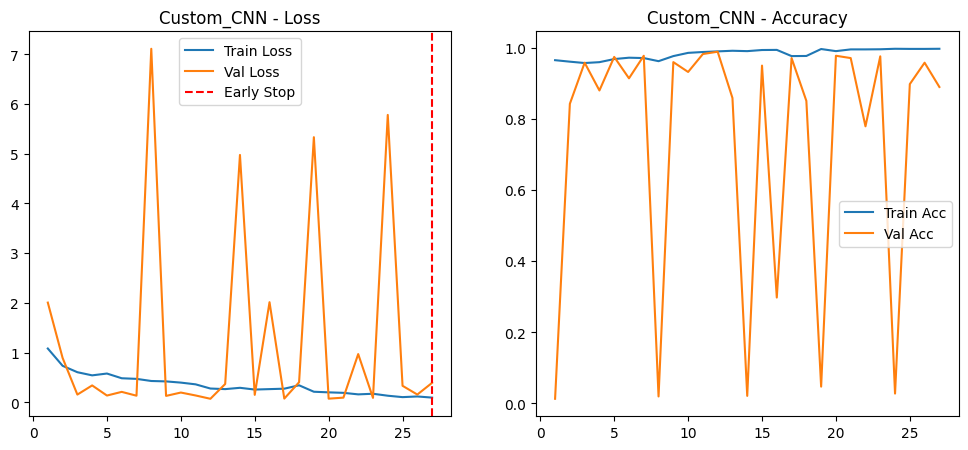

In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import copy as shatranj_copy  

print("Starting Training Engine")

def train_model(model, model_name, train_loader, val_loader, learning_rate, num_epochs=100, patience=15):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)
    
    best_val_loss = float('inf')
    epochs_no_improve = 0
    
    best_model_wts = shatranj_copy.deepcopy(model.state_dict())
    
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    early_stop_epoch = num_epochs
    
    for epoch in range(num_epochs):
        # TRAINING 
        model.train()
        run_loss, run_corrects, total = 0.0, 0, 0
        
        for inputs, labels in train_loader:
            if "ResNet" in model_name and inputs.shape[1] == 1:
                inputs = inputs.repeat(1, 3, 1, 1) 
                
            inputs, labels = inputs.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            _, preds = torch.max(outputs, 1)
            run_loss += loss.item() * inputs.size(0)
            run_corrects += torch.sum(preds == labels.data)
            total += labels.size(0)
            
        train_loss = run_loss / total
        train_acc = run_corrects.double() / total
        
        # VALIDATION
        model.eval()
        val_loss, val_corrects, val_total = 0.0, 0, 0
        
        with torch.no_grad():
            for inputs, labels in val_loader:
                if "ResNet" in model_name and inputs.shape[1] == 1:
                    inputs = inputs.repeat(1, 3, 1, 1)
                    
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                
                _, preds = torch.max(outputs, 1)
                val_loss += loss.item() * inputs.size(0)
                val_corrects += torch.sum(preds == labels.data)
                val_total += labels.size(0)
                
        val_loss = val_loss / val_total
        val_acc = val_corrects.double() / val_total
        
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc.item())
        history['val_acc'].append(val_acc.item())
        
        scheduler.step(val_loss)
        
        print(f"Epoch {epoch+1:03d} | Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")
        
        # EARLY STOPPING 
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            # Using the unique alias here too
            best_model_wts = shatranj_copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"Early stopping triggered at epoch {epoch+1}!")
                early_stop_epoch = epoch + 1
                break
                
    # Save Model Weights
    os.makedirs("../DATA/models", exist_ok=True)
    torch.save(best_model_wts, f"../DATA/models/{model_name}.pth")
    
    # PLOT CURVES
    epochs_range = range(1, len(history['train_loss']) + 1)
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, history['train_loss'], label='Train Loss')
    plt.plot(epochs_range, history['val_loss'], label='Val Loss')
    if early_stop_epoch < num_epochs:
        plt.axvline(x=early_stop_epoch, color='r', linestyle='--', label='Early Stop')
    plt.title(f'{model_name} - Loss')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, history['train_acc'], label='Train Acc')
    plt.plot(epochs_range, history['val_acc'], label='Val Acc')
    plt.title(f'{model_name} - Accuracy')
    plt.legend()
    plt.show()
    
    return model

# Training Start
custom_cnn = CustomShallowCNN(num_classes=5)
custom_cnn = train_model(custom_cnn, "Custom_CNN", train_loader, val_loader, learning_rate=1e-3)

Training ResNet-18 (Transfer Learning)...


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\Raghvendra Goyal/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth
100.0%


Epoch 001 | Train Loss: 0.8393 Acc: 0.7774 | Val Loss: 0.4670 Acc: 0.8813
Epoch 002 | Train Loss: 0.1167 Acc: 0.9923 | Val Loss: 0.2494 Acc: 0.9333
Epoch 003 | Train Loss: 0.0275 Acc: 0.9997 | Val Loss: 0.1124 Acc: 0.9707
Epoch 004 | Train Loss: 0.0128 Acc: 1.0000 | Val Loss: 0.0789 Acc: 0.9756
Epoch 005 | Train Loss: 0.0086 Acc: 1.0000 | Val Loss: 0.0921 Acc: 0.9740
Epoch 006 | Train Loss: 0.0071 Acc: 1.0000 | Val Loss: 0.1040 Acc: 0.9659
Epoch 007 | Train Loss: 0.0046 Acc: 1.0000 | Val Loss: 0.0997 Acc: 0.9707
Epoch 008 | Train Loss: 0.0039 Acc: 1.0000 | Val Loss: 0.0924 Acc: 0.9707
Epoch 009 | Train Loss: 0.0029 Acc: 1.0000 | Val Loss: 0.0732 Acc: 0.9756
Epoch 010 | Train Loss: 0.0026 Acc: 1.0000 | Val Loss: 0.0660 Acc: 0.9772
Epoch 011 | Train Loss: 0.0023 Acc: 1.0000 | Val Loss: 0.0919 Acc: 0.9691
Epoch 012 | Train Loss: 0.0020 Acc: 1.0000 | Val Loss: 0.0679 Acc: 0.9772
Epoch 013 | Train Loss: 0.0015 Acc: 1.0000 | Val Loss: 0.0681 Acc: 0.9756
Epoch 014 | Train Loss: 0.0015 Acc: 1.

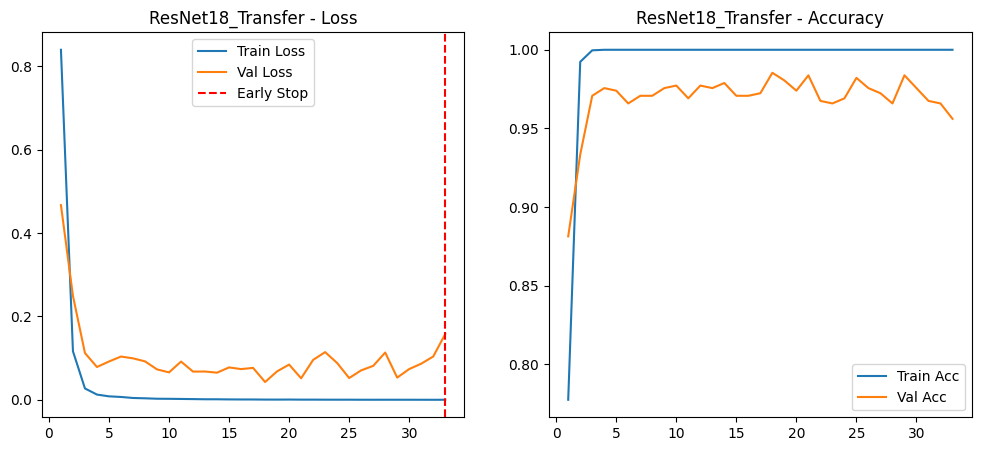

ResNet-18 Training & Plots done


In [ ]:
print("Training ResNet-18 (Transfer Learning)...")

# 1. Initialize ResNet-18
# PDF requirement: Pre-trained on ImageNet, 5 classes output
resnet_model = get_resnet18(num_classes=5)

# 2. Train ResNet-18 
# PDF: Fine-tuning with lower learning rate 1e-4
resnet_model = train_model(
    resnet_model, 
    "ResNet18_Transfer", 
    train_loader, 
    val_loader, 
    learning_rate=1e-4,
    num_epochs=100,
    patience=15
)


print("ResNet-18 Training & Plots done")

In [8]:
pip install opencv-python

^C
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/40.2 MB 217.9 kB/s eta 0:03:05
   ---------------------------------------- 0.0/40.2 MB 262.6 kB/s eta 0:02:34
   ---------------------------------------- 0.1/40.2 MB 853.3 kB/s eta 0:00:47
   ---------------------------------------- 0.3/40.2 MB 1.5 MB/s eta 0:00:28
   ---------------------------------------- 0.5/40.2 MB 2.0 MB/s eta 0:00:21
    --------------------------------------- 0.8/40.2 MB 2.6 MB/s eta 0:00:16
    --------------------------------------- 0.9/40.2 MB 2.7 MB/s eta 0:00:15
   - -------------------------------------- 1.1/40.2 MB 3.0 MB/s eta 0:00:14
   - -------------------------------------- 1.4/40.2 MB 3.2 MB/s eta 0:00:13
   - -------------------------------------- 1.5/40.2 MB 3.2 MB/s eta 0:00:13
   - -------------------------------------- 1.8/40.2 MB 3.4 MB/s eta 0:00:12
   - --

In [10]:
import cv2
print(cv2.__version__)


4.13.0


Grad-CAM heatmaps for all 5 classes


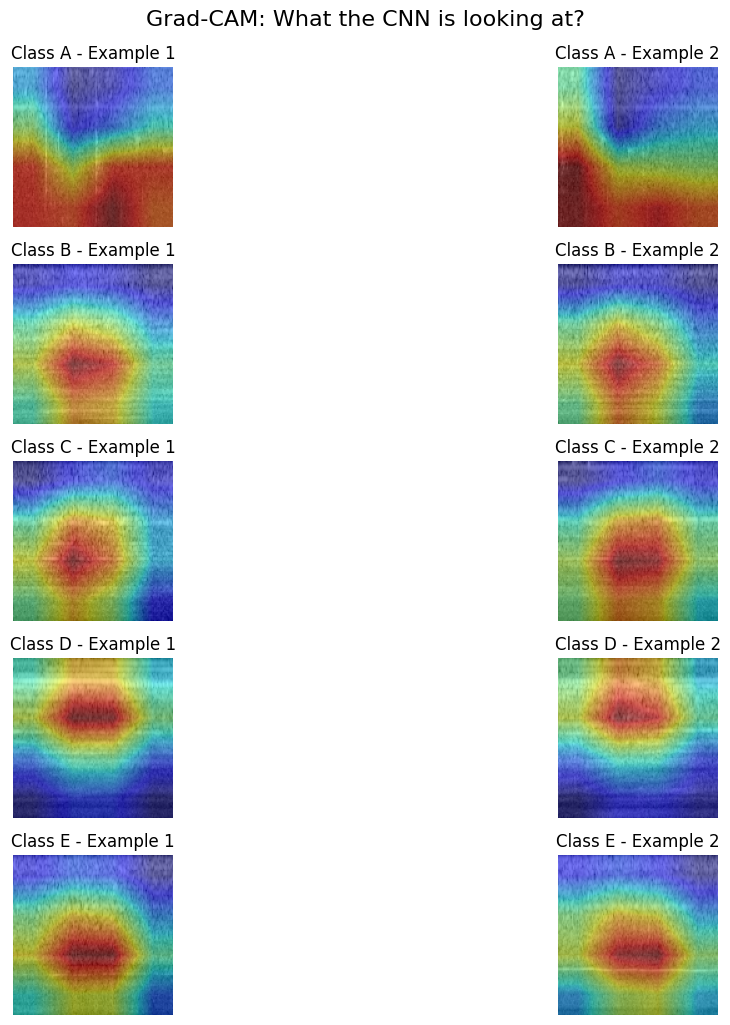

In [9]:
import torch.nn.functional as F
import cv2

print("Grad-CAM heatmaps for all 5 classes")

def generate_gradcam(model, input_tensor, target_class):
    model.eval()
    # we are trageting the last conv layer for both models, so we can use the same logic
    # For Custom CNN: model.block3[0] | For ResNet: model.layer4
    target_layer = model.layer4 if hasattr(model, 'layer4') else model.block3[0]
    
    # Hooks for Gradients and Activations store 
    gradients = []
    activations = []
    
    def save_gradient(grad): gradients.append(grad)
    def save_activation(module, input, output): activations.append(output)
    
    handle_g = target_layer.register_full_backward_hook(lambda m, i, o: save_gradient(o[0]))
    handle_a = target_layer.register_forward_hook(save_activation)
    
    # Forward pass
    output = model(input_tensor.to(device))
    loss = output[0, target_class]
    
    # Backward pass
    model.zero_grad()
    loss.backward()
    
    # Heatmap generation logic
    pooled_gradients = torch.mean(gradients[0], dim=[0, 2, 3])
    for i in range(activations[0].shape[1]):
        activations[0][:, i, :, :] *= pooled_gradients[i]
        
    heatmap = torch.mean(activations[0], dim=1).squeeze()
    heatmap = np.maximum(heatmap.cpu().detach().numpy(), 0)
    heatmap /= np.max(heatmap)
    
    # Cleanup hooks
    handle_g.remove()
    handle_a.remove()
    
    return heatmap

# Plotting Loop: 2 Examples per Class
classes = ['A', 'B', 'C', 'D', 'E'] # check your actual class names here
plt.figure(figsize=(15, 10))

for idx, cls_idx in enumerate(range(5)):
    # Find two samples of this class from validation set
    sample_indices = (y_val == cls_idx).nonzero(as_tuple=True)[0][:2]
    
    for i, s_idx in enumerate(sample_indices):
        img_tensor = X_val[s_idx].unsqueeze(0)
        # ResNet needs 3 channels
        if "ResNet" in str(type(resnet_model)):
            img_tensor = img_tensor.repeat(1, 3, 1, 1)
            
        heatmap = generate_gradcam(resnet_model, img_tensor, cls_idx)
        
        # Overlay heatmap on original spectrogram
        original_img = X_val[s_idx].numpy().squeeze()
        heatmap_resized = cv2.resize(heatmap, (128, 128))
        
        plt.subplot(5, 2, idx*2 + i + 1)
        plt.imshow(original_img, cmap='gray')
        plt.imshow(heatmap_resized, cmap='jet', alpha=0.5) # Heatmap overlay
        plt.title(f"Class {classes[cls_idx]} - Example {i+1}")
        plt.axis('off')

plt.tight_layout()
plt.suptitle("Grad-CAM: What the CNN is looking at?", fontsize=16, y=1.02)
plt.show()